# YOUR PROJECT TITLE

> **Note the following:** 
> 1. This is *not* meant to be an example of an actual **model analysis project**, just an example of how to structure such a project.
> 1. Remember the general advice on structuring and commenting your code
> 1. The `modelproject.py` file includes a function which could be used multiple times in this notebook.

Imports and set magics:

In [7]:
import numpy as np
from scipy import optimize
import sympy as sm

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# local modules
import modelproject

# Model description

Our project analyses the Overlapping generations (OLG) model. The OLG model is a cornerstone model of modern economics. It investigates intergeneraltional allocation and the life-cycle behavior (investment in human capital, work and saving for retirement). 

In the OLG model, we have 2 periods, one when individuals are young, period 1 and one when they are old, period t+1. 
Induviduals are born in period t.

$$L_t =L_{t+1}(1+n)$$

There are $L_t$ young people and $L_{t+1}$ old people. n is the population growth

**Firms**: We have in the OLG model that firms are competitive, identical and maximize their profits as such:

$$
\begin{aligned}
\pi_t & =\max_{K_{t},L_t} K_t^\alpha L_t^{1-\alpha}-r_tK_t-w_tL_t\\
\end{aligned}
$$
This is a Cobb-Douglas production-function. $K_{t}$ is the capital, $L_t$ is the labor, $\alpha$ is a parameter, $\in (0, 1)$.

We define kapital in per capita terms, and we have that the rent on capital is its marginal product. And the cost of labour is the wage which is also its marginal product.
$$
\begin{aligned}
k_t & =\frac{K_t}{L_t} \\
r_t & = \alpha  k_t^{\alpha-1} \\
w_t & = (1-\alpha)  k_t^{\alpha}
\end{aligned}
$$


The budget constraint for the young and old is: 

$$
c_{1t} + s_t = w_t 
$$

$$
c_{2t+1} = (1 + r_{t+1}) s_t
$$

The young consume their wage and saves for when they are old. The old then get these savings and the interest rate they got on the savings. 

The lifetime budget constraint then becomes:

$$c_{1t} + \frac{c_{2t+1}}{1+r_{t+1}} = w_t $$

The old consumes all of their remaining saved wages. We see that all consumtion comes from the wage made in period 1. 

Utility for the households is:
    
$$
\begin{aligned}
U_t & = u(c_{1t})+\frac{1}{1+\rho} u(c_{2t+1})\\
\end{aligned}
$$

$\rho$ is the discount rate, i.e. the measure of patience of the households, i.e. how much consumption the househoplds wants when young in period 1 and when old in period 2. A higher $\rho$ means more impatient households, $\rho \in (0,1)$.

We can now solve the households maximization problem:

$$ \max_{c_{1t}, c_{2t+1}} \left( u(c_{1t}) + \frac{1}{1+\rho} u(c_{2t+1}) \right) $$

Subject to the budget constraint:

$$ c_{1t} + \frac{c_{2t+1}}{1+r_{t+1}} = W_t $$

We can now solve this using sympy, and find the OLG-euler.

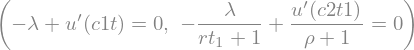

In [8]:
from sympy import symbols, Function, diff, Eq, solve, init_printing

init_printing()

# Define the symbols
c1t, c2t1, Wt, rt1, rho, lam = symbols('c1t c2t1 Wt rt1 rho lambda')

# Define the utility functions
u = Function('u')

# Define the Lagrangian
L = u(c1t) + 1 / (1 + rho) * u(c2t1) + lam * (Wt - c1t - c2t1 / (1 + rt1))

# Compute the first order conditions using simplified notation for derivatives
foc_c1t = diff(u(c1t), c1t) - lam
foc_c2t1 = diff(u(c2t1), c2t1) / (1 + rho) - lam / (1 + rt1)

# Representing derivatives as u' as requested
u_prime_c1t = symbols("u'(c1t)")
u_prime_c2t1 = symbols("u'(c2t1)")
foc_c1t = foc_c1t.subs(diff(u(c1t), c1t), u_prime_c1t)
foc_c2t1 = foc_c2t1.subs(diff(u(c2t1), c2t1), u_prime_c2t1)

# Format as equations
eq1 = Eq(foc_c1t, 0)
eq2 = Eq(foc_c2t1, 0)

eq1, eq2

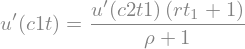

In [9]:
# Solve for lambda from eq1 and substitute in eq2
lambda_from_eq1 = solve(eq1, lam)[0]
euler_eq = eq2.subs(lam, lambda_from_eq1)

# Now solve the Euler equation for u_prime_c1t
euler_solution = solve(euler_eq, u_prime_c1t)

# Format the solution as an equation
euler_solution_eq = Eq(u_prime_c1t, euler_solution[0])

euler_solution_eq

We have now found the Euler equation for the OLG. If we combine the budget constraints with the euler we can find the optimal savings. 

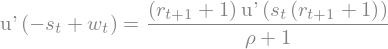

In [10]:
import sympy as sp

# Declare the variables
wt, st, rt1, rho = sp.symbols('w_t s_t r_{t+1} rho')

# Expressions for c1t and c2t+1
c1t = wt - st
c2t1 = (1 + rt1) * st

# Utility derivatives (we assume u'(x) is represented simply as u_prime(x))
u_prime = sp.Function('u\'')  # Define u' as a function

# Euler equation expressed in terms of st and wt
savings_rate = sp.Eq(u_prime(c1t), (1 + rt1) / (1 + rho) * u_prime(c2t1))

# Display the equation
savings_rate



From this we can isolate $s_t$ and get:

$$s_t=1/(2+\rho)wt

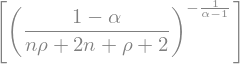

In [11]:

# Step 1: Define symbols
kt, kt1, n, rho, alpha, wt = sp.symbols('k_t k_{t+1} n rho alpha w_t')

# Step 2: Write the capital accumulation equation
equation = sp.Eq(kt1 * (1 + n), (1 / (2 + rho)) * (1 - alpha) * kt**alpha)

# Step 3: Solve for the steady state by setting kt1 = kt
steady_state_eq = equation.subs(kt1, kt)
steady_state_solution = sp.solve(steady_state_eq, kt)

steady_state_solution

We have steady state: 
$$
k^* = \left[ \frac{1 - \alpha}{(1 + n)(2 + \rho)} \right]^{\frac{1}{1-\alpha}}
$$

We can assign numeric values to $ n, \alpha, \rho $

In [12]:
Steady_state_nums = sm.lambdify((rho,alpha,n),steady_state_solution)
Steady_state_nums(0.03, 0.35, 0.02)

For the chosen parameter value, we find that steady state is $k^*=0.168$

We can now set up an algorithm that solves our steady state, we use the bisect method. 

In [13]:
from scipy import optimize

# Setting parameters
rho = 0.03
alpha = 0.35
n = 0.02

# We define the objective, The function calculates the difference between k and the expression, The goal is to find the value of k for which this difference is zero. 
obj = lambda k: k - (((1-alpha)*k**alpha)/((1+n)*(2+rho)))

# Optimizing the model and finding the roots with bisect
result = optimize.root_scalar(obj,bracket=[1e-10,10],method='bisect') 
result.root

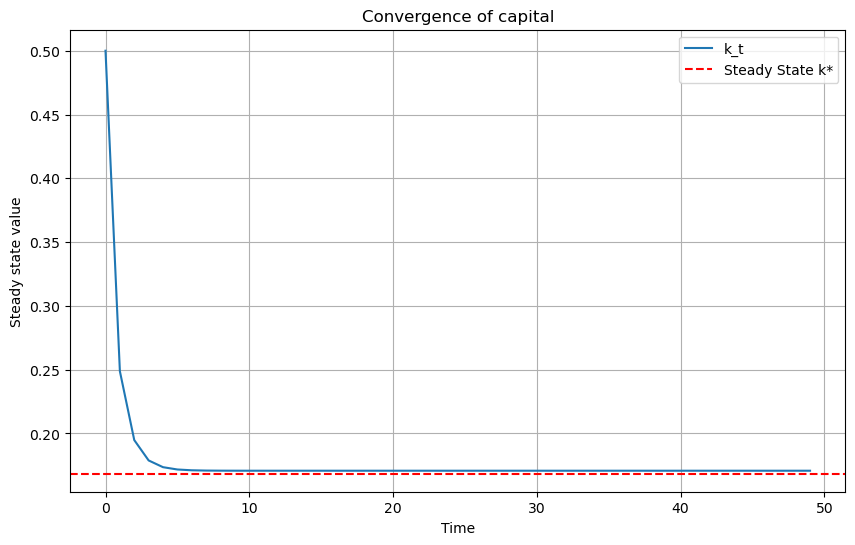

In [27]:
# Initial value for capital per capita
k_initial = 0.5  

# Initialize array to store simulation results
k = np.zeros(T)
k[0] = k_initial

# Simulation loop
for t in range(1, T):
    k[t] = ((1 - alpha) * k[t-1]**alpha) / ((1 + n) * (2 + rho))

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(k, label='k_t')  # Plotting k_t over time
plt.xlabel('Time')
plt.ylabel('Steady state value')
plt.title('Convergence of capital')
plt.axhline(y=0.168218026571459, color='r', linestyle='--', label='Steady State k*')
plt.legend()
plt.grid(True)
plt.show()

We see that k_t converges to the steady state after about 5 periods. There is convergence to the steady state value we found erlier.

You can always solve a model numerically. 

Define first the set of parameters you need. 

Then choose one of the optimization algorithms that we have gone through in the lectures based on what you think is most fitting for your model.

Are there any problems with convergence? Does the model converge for all starting values? Make a lot of testing to figure these things out. 

# Further analysis

Make detailed vizualizations of how your model changes with parameter values. 

Try to make an extension of the model. 

# Conclusion

Add concise conclusion. 